# 08-2 정규 표현식 시작하기

### 정규 표현식의 기초, 메타 문자

메타 문자란 원래 그 문자가 가진 뜻이 아니라 특별한 의미를 가진 문자를 말한다. 정규 표현식에 다음과 같은 메타 문자를 사용하면 특별한 의미를 갖게 된다.<br>
. ^ $ * + ? { } [ ] \ | ( )

즉, 정규 표현식이 [abc]라면 이 표현식의 의미는 ‘a, b, c 중 한 개의 문자와 매치’를 뜻한다. 이해를 돕기 위해 문자열 "a", "before", "dude"가 정규식 [abc]와 어떻게 매치되는지 살펴보자.

"a"는 정규식과 일치하는 문자인 "a"가 있으므로 매치된다.
"before"는 정규식과 일치하는 문자인 "b"가 있으므로 매치된다.
"dude"는 정규식과 일치하는 문자인 a, b, c 중 어느 하나도 포함하고 있지 않으므로 매치되지 않는다.

안의 두 문자 사이에 하이픈(-)을 사용하면 두 문자 사이의 범위를 의미한다
[a-c]라는 정규 표현식은 [abc]와 동일하고 [0-5]는 [012345]와 동일하다.

### .(dot) 문자 - \n을 제외한 모든 문자

a.b
"a + 모든_문자 + b"
"aab"는 가운데 문자 "a"가 모든 문자를 의미하는 .과 일치하므로 정규식과 매치된다.
"a0b"는 가운데 문자 "0"가 모든 문자를 의미하는 .과 일치하므로 정규식과 매치된다.
"abc"는 "a"문자와 "b"문자 사이에 어떤 문자라도 하나는 있어야 하는 이 정규식과 일치하지 않으므로 매치되지 않는다.

### * 문자

ca*t<br>
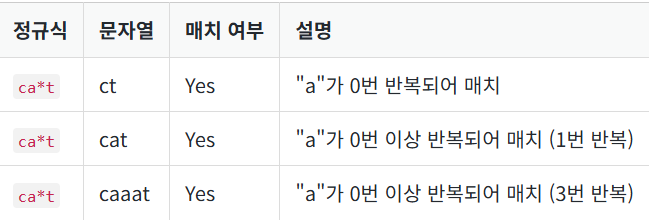

### + 문자

ca+t<br>
"c + a가_1번_이상_반복 + t" <br>
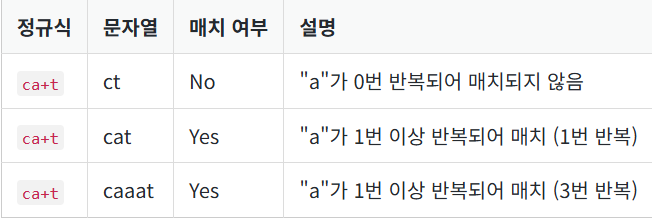

### {} 문자와 ? 문자

ca{2}t<br>
"c + a를_반드시_2번_반복 + t"<br>
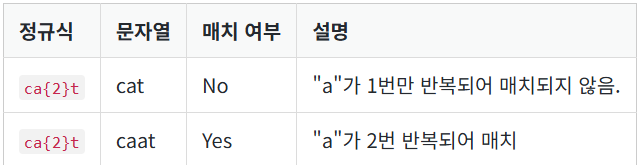


ca{2,5}t<br>
"c + a를_2~5회_반복 + t"<br>
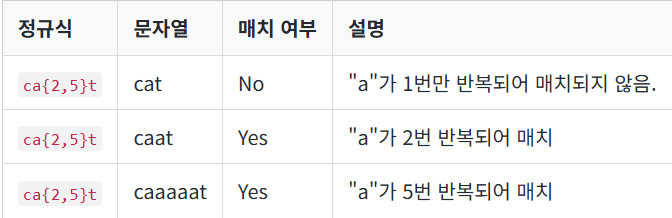

ab?c<br>
"a + b가_있어도_되고_없어도_됨 + c"<br>
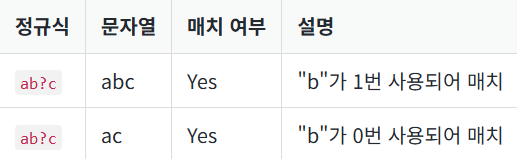

?는 한번 또는 0번을 의미한다.

### 파이썬에서 정규 표현식을 지원하는 re 모듈

In [1]:
import re
p = re.compile('ab*')

### 정규식을 이용한 문자열 검색

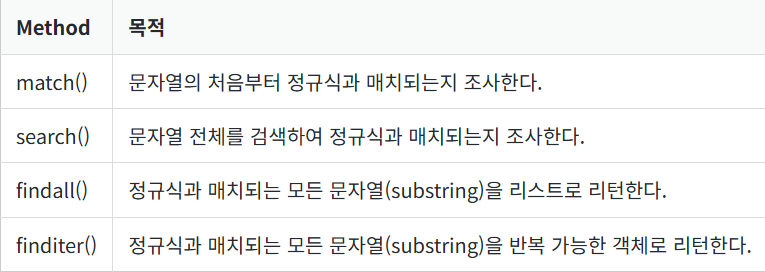

### match

In [2]:
import re
p = re.compile('[a-z]+')
m = p.match("python")
print(m)

<re.Match object; span=(0, 6), match='python'>


In [ ]:
import re
p = re.compile('[a-z]+')
m = p.match("3 python")
print(m)

None


매칭이 되지 않았기 떄문에 None을 출력한다.

### search

In [5]:
import re
p = re.compile('[a-z]+')
m = p.search("3 python")
print(m)

<re.Match object; span=(2, 8), match='python'>


매칭은 다 포함이 되어야지 매칭이 되는건데 <br>서치는 앞에서 매칭이 안되더라도 뒷부분에서 매칭이 된다면 매칭이 된다는 결과가 나온다.

### findall

In [6]:
import re
p = re.compile('[a-z]+')
result = p.findall("life is too short")
print(result)

['life', 'is', 'too', 'short']


findall은 패턴([a-z]+)과 매치되는 모든 값을 찾아 리스트로 리턴한다.

### finditer

In [7]:
import re
p = re.compile('[a-z]+')
result = p.findall("life is too short")
for r in result: 
    print(r)

life
is
too
short


finditer는 findall과 동일하지만, 그 결과로 반복 가능한 객체(iterator object)를 리턴한다. 그리고 반복 가능한 객체가 포함하는 각각의 요소는 match 객체이다.

### match 객체의 메서드

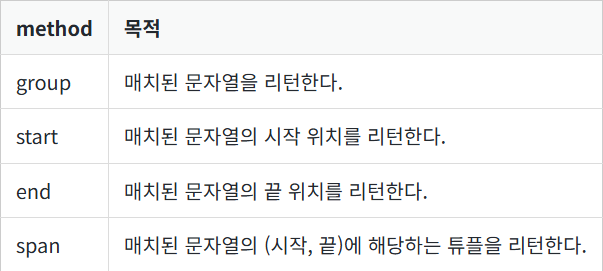

In [9]:
import re
p = re.compile('[a-z]+')
m = p.match("python")
print(m.group())
print(m.start())
print(m.end())
print(m.span())

python
0
6
(0, 6)


In [13]:
import re
p = re.compile('[a-z]+')
m = p.search("3 python")
print(m.group())
print(m.start())
print(m.end())
print(m.span())

python
2
8
(2, 8)


### 컴파일 옵션

DOTALL(S) - .(dot)이 줄바꿈 문자를 포함해 모든 문자와 매치될 수 있게 한다.<br>
IGNORECASE(I) - 대소문자에 관계없이 매치될 수 있게 한다.<br>
MULTILINE(M) - 여러 줄과 매치될 수 있게 한다. ^, $ 메타 문자 사용과 관계 있는 옵션이다.<br>
VERBOSE(X) - verbose 모드를 사용할 수 있게 한다. 정규식을 보기 편하게 만들 수 있고 주석 등을 사용할 수 있게 된다.

### DOTALL, S

. 메타 문자는 줄바꿈 문자(\n)를 제외한 모든 문자와 매치되는 규칙이 있다. 만약 \n 문자도 포함하여 매치하고 싶다면 re.DOTALL 또는 re.S 옵션을 사용해 정규식을 컴파일하면 된다

In [ ]:
import re
p = re.compile('a.b')
m = p.match('a\nb')
print(m)

<re.Match object; span=(0, 3), match='a\nb'>


In [17]:
import re
p = re.compile('a.b',re.DOTALL)
m = p.match('a\nb')
print(m)

<re.Match object; span=(0, 3), match='a\nb'>


### IGNORECASE, I

re.IGNORECASE 또는 re.I 옵션은 대소문자 구별 없이 매치를 수행할 때 사용하는 옵션이다. 다음 예제를 살펴보자.

In [18]:
import re
p = re.compile('[a-z]+', re.I)
m = p.match("python")
print(p.match('python'))
print(p.match('Python'))
print(p.match('PYTHON'))

<re.Match object; span=(0, 6), match='python'>
<re.Match object; span=(0, 6), match='Python'>
<re.Match object; span=(0, 6), match='PYTHON'>


### MULTILINE, M

^는 문자열의 처음, $는 문자열의 마지막을 의미한다. ^python인 경우, 문자열의 처음은 항상 python으로 시작해야 매치되고 만약 정규식이 python$이라면 문자열의 마지막은 항상 python으로 끝나야 매치된다는 의미이다.

In [19]:
# multiline.py
import re
p = re.compile("^python\s\w+")

data = """python one
life is too short
python two
you need python
python three"""

print(p.findall(data))

['python one']


In [20]:
# multiline.py
import re
p = re.compile("^python\s\w+", re.MULTILINE)

data = """python one
life is too short
python two
you need python
python three"""

print(p.findall(data))

['python one', 'python two', 'python three']


### VERBOSE, X

In [21]:
charref = re.compile(r'&[#](0[0-7]+|[0-9]+|x[0-9a-fA-F]+);')

In [22]:
charref = re.compile(r"""
 &[#]                # Start of a numeric entity reference
 (
     0[0-7]+         # Octal form
   | [0-9]+          # Decimal form
   | x[0-9a-fA-F]+   # Hexadecimal form
 )
 ;                   # Trailing semicolon
""", re.VERBOSE)

re.VERBOSE 옵션을 사용하면 문자열에 사용된 화이트스페이스는 컴파일할 때 제거된다(단, [ ] 안에 사용한 화이트스페이스는 제외).

### 역슬래시 문제

aw string 표현법을 사용해야 한다.

In [ ]:
p = re.compile(r'\\section')